<a href="https://colab.research.google.com/github/PeroronShine/education_fefu_2/blob/main/AI_prog/ML_laba5_IMDb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split


In [ ]:
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
imdb_path = kagglehub.dataset_download("talhasiddique123/imdb-latest2025-top-250-rated-movies")

print(f'Data source import complete. Files saved to: {imdb_path}')

100%|██████████| 27.7k/27.7k [00:00<00:00, 17.8MB/s]

Extracting files...
Data source import complete. Files saved to: /root/.cache/kagglehub/datasets/talhasiddique123/imdb-latest2025-top-250-rated-movies/versions/1


In [ ]:
csv_files = [f for f in os.listdir(imdb_path) if f.endswith('.csv')]
csv_file = csv_files[0]
csv_path = os.path.join(imdb_path, csv_file)

print(f'Найден файл: {csv_file}')

df = pd.read_csv(csv_path)
print(f'\nРазмер датасета: {df.shape}')
print('\nПервые 5 строк:')
print(df.head())

print(df.info())

Найден файл: IMDbmovies250.csv

Размер датасета: (250, 11)

Первые 5 строк:
   Unnamed: 0         id             originalTitle  \
0           0  tt0111161  The Shawshank Redemption   
1           1  tt0068646             The Godfather   
2           2  tt0468569           The Dark Knight   
3           3  tt0071562     The Godfather Part II   
4           4  tt0050083              12 Angry Men   

                                         description contentRating  \
0  A banker convicted of uxoricide forms a friend...             R   
1  The aging patriarch of an organized crime dyna...             R   
2  When a menace known as the Joker wreaks havoc ...         PG-13   
3  The early life and career of Vito Corleone in ...             R   
4  The jury in a New York City murder trial is fr...      Approved   

        budget  grossWorldwide                        genres  isAdult  \
0   25000000.0    2.933403e+07                     ['Drama']    False   
1    6000000.0    2.503422e+08  

In [ ]:
data = df.copy()

data.drop(columns=['Unnamed: 0', 'id', 'originalTitle', 'description'], inplace=True, errors='ignore')

data['genres'] = data['genres'].apply(eval)
data['Genre_Count'] = data['genres'].apply(len)

top_genres = ['Drama', 'Crime', 'Action', 'Adventure', 'Sci-Fi', 'Thriller', 'Biography']
for genre in top_genres:
    data[f'Has_{genre}'] = data['genres'].apply(lambda x: genre in x).astype(int)

data.drop(columns=['genres'], inplace=True)

data['contentRating'].fillna('Unknown', inplace=True)
content_dummies = pd.get_dummies(data['contentRating'], prefix='Rating')
data = pd.concat([data, content_dummies], axis=1)
data.drop(columns=['contentRating'], inplace=True)

data['log_budget'] = np.log1p(data['budget'])
data['log_gross'] = np.log1p(data['grossWorldwide'])
data['profit'] = data['grossWorldwide'] - data['budget']
data['log_profit'] = np.log1p(data['profit'].clip(lower=0))

data['log_budget'].fillna(data['log_budget'].median(), inplace=True)
data['log_profit'].fillna(data['log_profit'].median(), inplace=True)

data.drop(columns=['budget', 'grossWorldwide', 'profit'], inplace=True)

data['isAdult'] = data['isAdult'].astype(int)

X = data.drop(columns=['averageRating'])
y = data['averageRating']

print(f"Количество признаков: {X.shape[1]}")
print("Пример фичей:")
print(X.head(3))

Количество признаков: 23
Пример фичей:
   isAdult  numVotes  Genre_Count  Has_Drama  Has_Crime  Has_Action  \
0        0   3100661            1          1          0           0   
1        0   2160925            2          1          1           0   
2        0   3075670            3          1          1           1   

   Has_Adventure  Has_Sci-Fi  Has_Thriller  Has_Biography  ...  \
0              0           0             0              0  ...   
1              0           0             0              0  ...   
2              0           0             0              0  ...   

   Rating_Not Rated  Rating_PG  Rating_PG-13  Rating_Passed  Rating_R  \
0             False      False         False          False      True   
1             False      False         False          False      True   
2             False      False          True          False     False   

   Rating_TV-MA  Rating_Unknown  log_budget  log_gross  log_profit  
0         False           False   17.034386  17.1

/tmp/ipython-input-317816178.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['contentRating'].fillna('Unknown', inplace=True)
/tmp/ipython-input-317816178.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"=== Модель: LinearRegression ===")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")

=== Модель: LinearRegression ===
MAE: 0.150
R²: 0.156


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"=== Ridge Regression ===")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")

=== Ridge Regression ===
MAE: 0.149
R²: 0.168


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"=== Модель: RandomForestRegressor===")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")

=== Модель: RandomForestRegressor===
MAE: 0.143
R²: 0.272



ТОП-10 важных признаков:
numVotes         0.635256
log_budget       0.118277
log_gross        0.091211
log_profit       0.047650
Genre_Count      0.017710
Has_Adventure    0.010581
Rating_PG        0.010376
Has_Crime        0.010296
Has_Thriller     0.008744
Has_Action       0.008156
dtype: float64


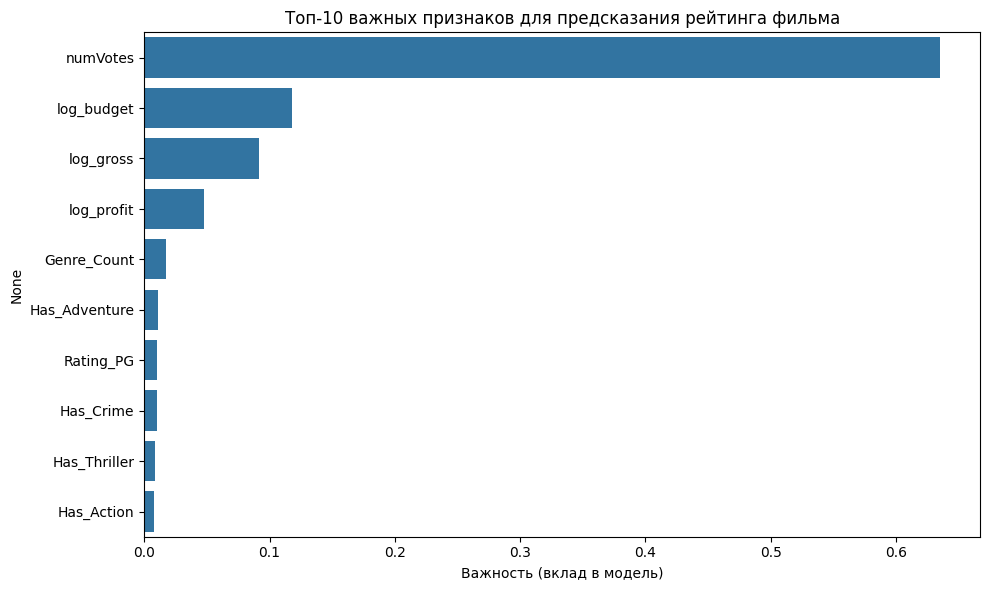

In [ ]:
feat_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nТОП-10 важных признаков:")
print(feat_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.head(10).values, y=feat_importance.head(10).index)
plt.title("Топ-10 важных признаков для предсказания рейтинга фильма")
plt.xlabel("Важность (вклад в модель)")
plt.tight_layout()
plt.show()